In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from Bio.Seq import Seq
sns.set_palette('colorblind')

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [2]:
df =  pd.read_csv('/grid/kinney/data/desmara/2025_12_03_pac_bio_library_mapping_risLlib_001_002_003_004/parsing/output/parse_v5/parsed_reads_merged.csv')
df

/tmp/ipykernel_1582095/4162126782.py:1: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df =  pd.read_csv('/grid/kinney/data/desmara/2025_12_03_pac_bio_library_mapping_risLlib_001_002_003_004/parsing/output/parse_v5/parsed_reads_merged.csv')


,query_name,file_name,upstream_barcode,upstream_barcode_rev,downstream_barcode,downstream_barcode_rev,lib001_variable_exon,lib001_variable_exon_rev,lib001_variable_intron,lib001_variable_intron_rev,lib002_variable_exon,lib002_variable_exon_rev,lib002_variable_intron,lib002_variable_intron_rev,lib003_variable_exon,lib003_variable_exon_rev,lib004_junction,lib004_junction_rev
0,m84223_251126_143521_s2/217779628/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,TTACTA,NaN,GGCTAGCTAACATCAGAGAG,NaN,GTTCTTCCTGCTGAGTTGTGTTCCATATCATCTTTGTCTTTACTTA...,NaN,TTGTAGCTATCATACTTCGTTGGCAGTTTGGACTGGGTGT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,m84223_251126_143521_s2/210309522/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,GACATA,NaN,GACATAATTCCTGGGTTGAC,NaN,AGTTTATATTAATCGCATCTGGTTTTTAGATAGTGTGTGTCTTTAC...,NaN,CGGGTCGAAAGAAACTTTTTTTTATTATTAAAATAACGTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,m84223_251126_143521_s2/234820256/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,m84223_251126_143521_s2/249957577/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,m84223_251126_143521_s2/259592903/ccs,m84223_251126_143521_s2.hifi_reads.bc2011.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12117574,m84223_251126_143521_s2/197597117/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12117575,m84223_251126_143521_s2/218894526/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12117576,m84223_251126_143521_s2/140907889/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12117577,m84223_251126_143521_s2/192090172/ccs,m84223_251126_143521_s2.hifi_reads.unassigned.bam,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.groupby('file_name').count()

,query_name,upstream_barcode,upstream_barcode_rev,downstream_barcode,downstream_barcode_rev,lib001_variable_exon,lib001_variable_exon_rev,lib001_variable_intron,lib001_variable_intron_rev,lib002_variable_exon,lib002_variable_exon_rev,lib002_variable_intron,lib002_variable_intron_rev,lib003_variable_exon,lib003_variable_exon_rev,lib004_junction,lib004_junction_rev
file_name,,,,,,,,,,,,,,,,,
m84223_251126_143521_s2.hifi_reads.bc2011.bam,6424942,3040275,2201479,3169289,2298010,2855659,2055158,2950447,2123478,1211,979,1184,950,46940,42391,3,2
m84223_251126_143521_s2.hifi_reads.bc2015.bam,5661978,2658270,1966004,2768660,2051565,1195,959,1036,819,2516885,1852252,2598932,1912568,111,93,40277,38653
m84223_251126_143521_s2.hifi_reads.unassigned.bam,30659,13766,10592,14420,11087,5618,4361,5762,4462,7134,5396,7343,5553,86,71,105,103


In [4]:
print('Consolidating forward and reverse BCs')
to_consolidate = df.copy()
cols_to_flip = ['upstream_barcode', 'downstream_barcode', 'lib001_variable_exon', 'lib001_variable_intron', 'lib002_variable_exon', 'lib002_variable_intron', 'lib003_variable_exon', 'lib004_junction']
for col in cols_to_flip:
    mask = to_consolidate[col].isna()&(~to_consolidate[f'{col}_rev'].isna())
    to_consolidate.loc[mask, col] = to_consolidate.loc[mask, f'{col}_rev'].apply(lambda x: str(Seq(str(x)).reverse_complement()))


to_consolidate = to_consolidate.drop(columns=[f'{col}_rev' for col in cols_to_flip])
to_consolidate['file_name'] = to_consolidate['file_name'].str.split('.').str[-2]
to_consolidate

Consolidating forward and reverse BCs


,query_name,file_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction
0,m84223_251126_143521_s2/217779628/ccs,bc2011,TTACTA,GGCTAGCTAACATCAGAGAG,GTTCTTCCTGCTGAGTTGTGTTCCATATCATCTTTGTCTTTACTTA...,TTGTAGCTATCATACTTCGTTGGCAGTTTGGACTGGGTGT,NaN,NaN,NaN,NaN
1,m84223_251126_143521_s2/210309522/ccs,bc2011,GACATA,GACATAATTCCTGGGTTGAC,AGTTTATATTAATCGCATCTGGTTTTTAGATAGTGTGTGTCTTTAC...,CGGGTCGAAAGAAACTTTTTTTTATTATTAAAATAACGTC,NaN,NaN,NaN,NaN
2,m84223_251126_143521_s2/234820256/ccs,bc2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,m84223_251126_143521_s2/249957577/ccs,bc2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,m84223_251126_143521_s2/259592903/ccs,bc2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
12117574,m84223_251126_143521_s2/197597117/ccs,unassigned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12117575,m84223_251126_143521_s2/218894526/ccs,unassigned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12117576,m84223_251126_143521_s2/140907889/ccs,unassigned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12117577,m84223_251126_143521_s2/192090172/ccs,unassigned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
to_consolidate.groupby('file_name').count()

,query_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction
file_name,,,,,,,,,
bc2011,6424942,5241700,5467224,4910785,5073871,2190,2134,89331,5
bc2015,5661978,4624226,4820177,2154,1855,4369105,4511458,204,78930
unassigned,30659,24351,25501,9977,10222,12528,12893,157,208


In [6]:
to_count = to_consolidate.copy()
to_count['has_BC'] = (~to_count.upstream_barcode.isna())&(~to_count.downstream_barcode.isna())
to_count['has_lib1_VC'] = (~to_count.lib001_variable_exon.isna())&(~to_count.lib001_variable_intron.isna())
to_count['has_lib2_VC'] = (~to_count.lib002_variable_exon.isna())&(~to_count.lib002_variable_intron.isna())
to_count['has_lib3_VC'] = (~to_count.lib003_variable_exon.isna())
to_count['has_lib4_VC'] = (~to_count.lib004_junction.isna())
counted = to_count.groupby(['file_name'])[['has_BC', 'has_lib1_VC', 'has_lib2_VC', 'has_lib3_VC', 'has_lib4_VC']].sum()
counted


,has_BC,has_lib1_VC,has_lib2_VC,has_lib3_VC,has_lib4_VC
file_name,,,,,
bc2011,5142034,4820177,2034,89331,5
bc2015,4537429,1735,4291542,204,78930
unassigned,23542,9622,12174,157,208


In [7]:
to_count

,query_name,file_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction,has_BC,has_lib1_VC,has_lib2_VC,has_lib3_VC,has_lib4_VC
0,m84223_251126_143521_s2/217779628/ccs,bc2011,TTACTA,GGCTAGCTAACATCAGAGAG,GTTCTTCCTGCTGAGTTGTGTTCCATATCATCTTTGTCTTTACTTA...,TTGTAGCTATCATACTTCGTTGGCAGTTTGGACTGGGTGT,NaN,NaN,NaN,NaN,True,True,False,False,False
1,m84223_251126_143521_s2/210309522/ccs,bc2011,GACATA,GACATAATTCCTGGGTTGAC,AGTTTATATTAATCGCATCTGGTTTTTAGATAGTGTGTGTCTTTAC...,CGGGTCGAAAGAAACTTTTTTTTATTATTAAAATAACGTC,NaN,NaN,NaN,NaN,True,True,False,False,False
2,m84223_251126_143521_s2/234820256/ccs,bc2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
3,m84223_251126_143521_s2/249957577/ccs,bc2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
4,m84223_251126_143521_s2/259592903/ccs,bc2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12117574,m84223_251126_143521_s2/197597117/ccs,unassigned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
12117575,m84223_251126_143521_s2/218894526/ccs,unassigned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
12117576,m84223_251126_143521_s2/140907889/ccs,unassigned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
12117577,m84223_251126_143521_s2/192090172/ccs,unassigned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False


In [26]:
mixed = (to_count.has_lib1_VC.astype(int)+to_count.has_lib2_VC.astype(int)+to_count.has_lib3_VC.astype(int)+to_count.has_lib4_VC.astype(int)) > 1
mixed.sum()

np.int64(1233)

In [8]:
to_count['library_assignment'] = 'None'
to_count.loc[to_count.has_BC&to_count.has_lib1_VC&~to_count.has_lib2_VC&~to_count.has_lib3_VC&~to_count.has_lib4_VC, 'library_assignment'] = 'lib1'
to_count.loc[to_count.has_BC&~to_count.has_lib1_VC&to_count.has_lib2_VC&~to_count.has_lib3_VC&~to_count.has_lib4_VC, 'library_assignment'] = 'lib2'
to_count.loc[to_count.has_BC&~to_count.has_lib1_VC&~to_count.has_lib2_VC&to_count.has_lib3_VC&~to_count.has_lib4_VC, 'library_assignment'] = 'lib3'
to_count.loc[to_count.has_BC&~to_count.has_lib1_VC&~to_count.has_lib2_VC&~to_count.has_lib3_VC&to_count.has_lib4_VC, 'library_assignment'] = 'lib4'


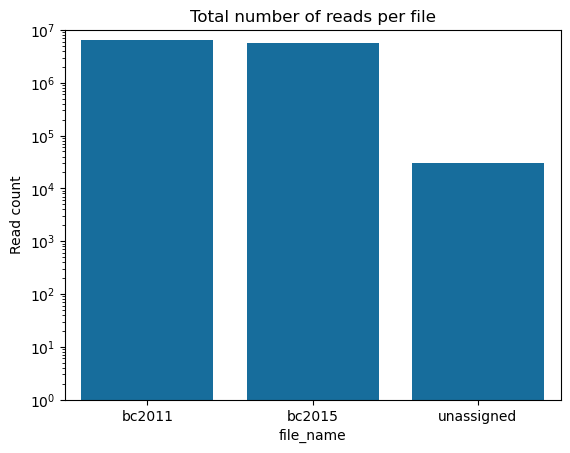

In [9]:
sns.barplot(data=to_count.file_name.value_counts().rename('Read count').reset_index(), x='file_name', y='Read count', order=['bc2011', 'bc2015', 'unassigned'])
plt.yscale('log')
plt.ylim(1, 1e7)
plt.title('Total number of reads per file')
plt.show()


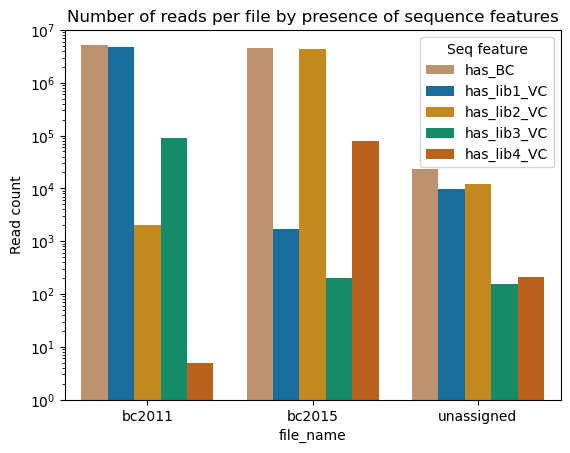

In [21]:
sns.barplot(data=counted.stack().rename('Read count').reset_index().rename(columns={'level_1': 'Seq feature'}), x='file_name', y='Read count', order=['bc2011', 'bc2015', 'unassigned'],
            hue='Seq feature', hue_order=['has_BC', 'has_lib1_VC', 'has_lib2_VC', 'has_lib3_VC', 'has_lib4_VC'], palette=[sns.color_palette('colorblind')[5]]+sns.color_palette('colorblind')[0:4])
plt.yscale('log')
plt.ylim(1, 1e7)
plt.title('Number of reads per file by presence of sequence features')
plt.show()

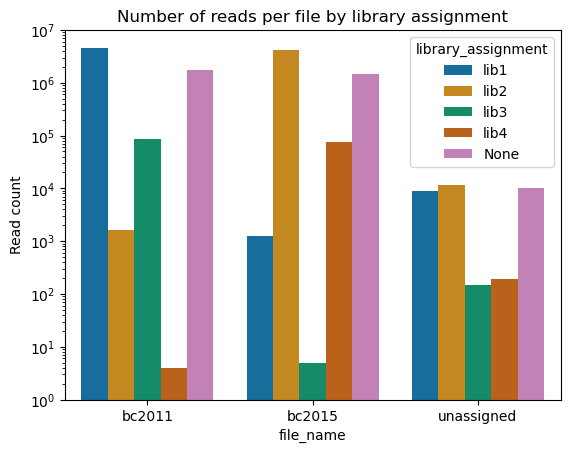

In [30]:
sns.barplot(data=to_count.groupby(['file_name', 'library_assignment'])['query_name'].count().rename('Read count').reset_index(), x='file_name', y='Read count', 
            hue='library_assignment', hue_order=['lib1', 'lib2', 'lib3', 'lib4', 'None'], order=['bc2011', 'bc2015', 'unassigned'])
plt.yscale('log')
plt.ylim(1, 1e7)
plt.title('Number of reads per file by library assignment')
plt.show()


In [41]:
has_BC = (~to_consolidate.upstream_barcode.isna() & ~to_consolidate.downstream_barcode.isna())
has_lib1_VC = (~to_consolidate.lib001_variable_exon.isna() & ~to_consolidate.lib001_variable_intron.isna())
has_lib2_VC = (~to_consolidate.lib002_variable_exon.isna() & ~to_consolidate.lib002_variable_intron.isna())
has_lib3_VC = (~to_consolidate.lib003_variable_exon.isna())
has_lib4_VC = (~to_consolidate.lib004_junction.isna())
keep_mask = has_BC&((has_lib1_VC)|(has_lib2_VC)|(has_lib3_VC)|(has_lib4_VC))
valid_reads = to_consolidate[keep_mask]
print(f'Filtering to reads with valid VR and BC, {keep_mask.sum()} ({keep_mask.sum()/len(keep_mask):.2%}) reads remaining')
valid_reads

Filtering to reads with valid VR and BC, 8914127 (73.56%) reads remaining


,query_name,file_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction
0,m84223_251126_143521_s2/217779628/ccs,bc2011,TTACTA,GGCTAGCTAACATCAGAGAG,GTTCTTCCTGCTGAGTTGTGTTCCATATCATCTTTGTCTTTACTTA...,TTGTAGCTATCATACTTCGTTGGCAGTTTGGACTGGGTGT,NaN,NaN,NaN,NaN
1,m84223_251126_143521_s2/210309522/ccs,bc2011,GACATA,GACATAATTCCTGGGTTGAC,AGTTTATATTAATCGCATCTGGTTTTTAGATAGTGTGTGTCTTTAC...,CGGGTCGAAAGAAACTTTTTTTTATTATTAAAATAACGTC,NaN,NaN,NaN,NaN
25,m84223_251126_143521_s2/262803812/ccs,bc2011,TCTCAA,ATTTAGGCCAAAATAATTT,ATTGTTCACTGGTAGCGAGCGCAGGGAAATGGCAAATAAATATACG...,TAGCGAGTCAGAATTAAAAACACTCGCAGACAGGTATGCA,NaN,NaN,NaN,NaN
26,m84223_251126_143521_s2/210376133/ccs,bc2011,TTGCTG,TATCACGACCTGATGGCAAA,GTAAATATCTCTCAGTTTTCTGAGTTGTGTTGGTATATTCATGGTT...,CATTAAGACAGGACATGAAATGGGTATTATTAATCCTGCA,NaN,NaN,NaN,NaN
27,m84223_251126_143521_s2/209064413/ccs,bc2011,TTCACT,AGGTGATACTGAGTTGTGTG,TTTAGACTGGATTATTCGTCTTCTTCTTTTTCATGAAAAATCGGTA...,CTAACGCAGCGCTTCTTGTTTGTATAACTATTTACTTGCC,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
12117527,m84223_251126_143521_s2/115413982/ccs,unassigned,ACTGCA,ACCTGAGTAACCAATCCAGA,NaN,NaN,ATCGCTAGTAAGTAGTTTTGTGCCTGGGCATGCCGGTTGCACTGAG...,GCCCCATCCCGTTGAGGTCCAGCCTAGGTTTTCATTCGAG,NaN,NaN
12117530,m84223_251126_143521_s2/166729510/ccs,unassigned,AATATC,GCCAACCATACTCGTCCTAA,TATCTTACGTCATATCGTTCTTTAAACCTTCAATTCGTCATCGCAC...,GTGATTAAAGGTAGGTTAGGATGATTCTTCGTTTGTGTCT,NaN,NaN,NaN,NaN
12117531,m84223_251126_143521_s2/226102575/ccs,unassigned,CAAATG,TCCTGACGTATCGCACGGTA,NaN,NaN,TATAAATCTTGATAAGTTAGGGTTTTCTGAGACGTTAACCAAGCGC...,TAATTAATCAATTCCGGGATTCGATGGCGTTCGATTCACC,NaN,NaN
12117532,m84223_251126_143521_s2/144707090/ccs,unassigned,CTTTCA,GGGACTCAAATATTATCCAT,GGTTTAATTATCCGTCTTATTCAGGTATGCACAATTGTAACAAAAC...,CTTAATTTAGTTATGGGCTACGCAATTGGCGCAGAGCTTC,NaN,NaN,NaN,NaN


/tmp/ipykernel_1540095/1656222831.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_reads['library_assignment'] = 'None'


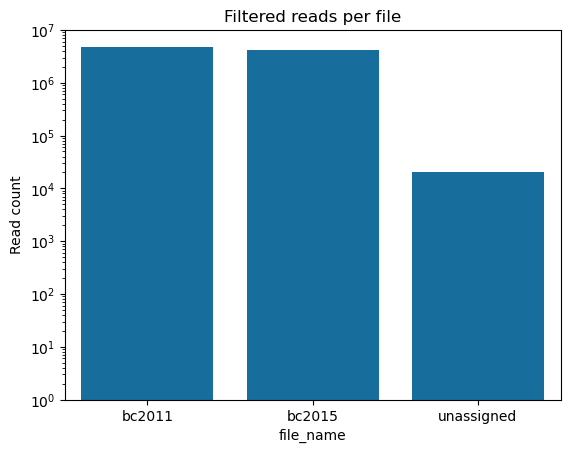

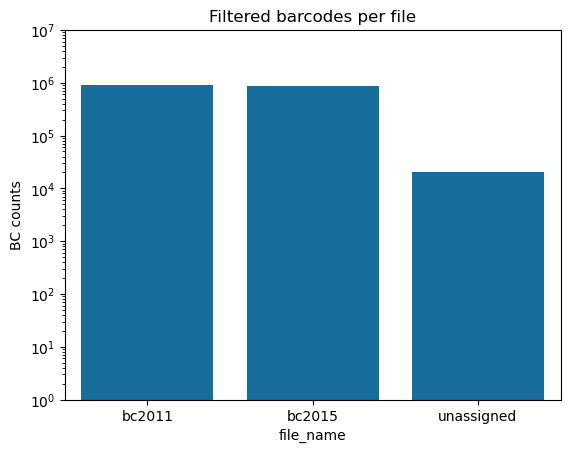

In [46]:
valid_reads['library_assignment'] = 'None'
lib1_mask = (valid_reads.lib001_variable_exon.notna() & valid_reads.lib001_variable_intron.notna())
lib2_mask = (valid_reads.lib002_variable_exon.notna() & valid_reads.lib002_variable_intron.notna())
lib3_mask = (valid_reads.lib003_variable_exon.notna())
lib4_mask = (valid_reads.lib004_junction.notna())
valid_reads.loc[lib1_mask&~lib2_mask&~lib3_mask&~lib4_mask, 'library_assignment'] = 'lib1'
valid_reads.loc[~lib1_mask&lib2_mask&~lib3_mask&~lib4_mask, 'library_assignment'] = 'lib2'
valid_reads.loc[~lib1_mask&~lib2_mask&lib3_mask&~lib4_mask, 'library_assignment'] = 'lib3'
valid_reads.loc[~lib1_mask&~lib2_mask&~lib3_mask&lib4_mask, 'library_assignment'] = 'lib4'

sns.barplot(data=valid_reads.file_name.value_counts().rename('Read count').reset_index(), x='file_name', y='Read count', order=['bc2011', 'bc2015', 'unassigned'])
plt.yscale('log')
plt.ylim(1, 1e7)
plt.title('Filtered reads per file')
plt.show()

sns.barplot(data=(valid_reads['upstream_barcode']+valid_reads['downstream_barcode']).groupby(valid_reads['file_name']).nunique().rename('BC counts').reset_index(), x='file_name', y='BC counts', order=['bc2011', 'bc2015', 'unassigned'])
plt.yscale('log')
plt.ylim(1, 1e7)
plt.title('Filtered barcodes per file')
plt.show()


,file_name,library_assignment,Read count
0,bc2011,None,575
1,bc2011,lib1,4619542
2,bc2011,lib2,1656
3,bc2011,lib3,85259
4,bc2011,lib4,4
5,bc2015,None,590
6,bc2015,lib1,1252
7,bc2015,lib2,4109138
8,bc2015,lib3,5
9,bc2015,lib4,75486


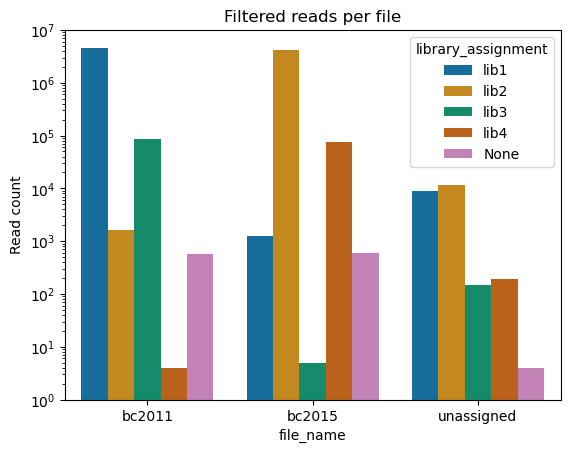

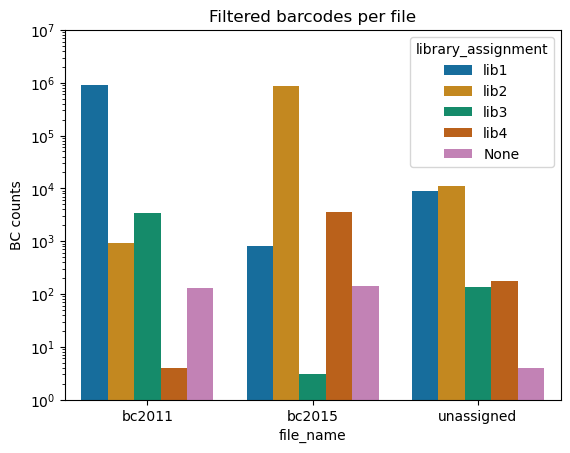

In [49]:
sns.barplot(data=valid_reads.groupby(['file_name', 'library_assignment'])['query_name'].count().rename('Read count').reset_index(), x='file_name', y='Read count', 
            hue='library_assignment', hue_order=['lib1', 'lib2', 'lib3', 'lib4', 'None'], order=['bc2011', 'bc2015', 'unassigned'])
plt.yscale('log')
plt.ylim(1, 1e7)
plt.title('Filtered reads per file')
plt.show()

sns.barplot(data=(valid_reads['upstream_barcode']+valid_reads['downstream_barcode']).groupby([valid_reads['file_name'], valid_reads['library_assignment']]).nunique().rename('BC counts').reset_index(), x='file_name', y='BC counts', order=['bc2011', 'bc2015', 'unassigned'],
            hue='library_assignment', hue_order=['lib1', 'lib2', 'lib3', 'lib4', 'None'])
plt.yscale('log')
plt.ylim(1, 1e7)
plt.title('Filtered barcodes per file')
plt.show()

In [50]:
pair_counts = valid_reads.groupby(['file_name','upstream_barcode', 'downstream_barcode','lib001_variable_exon','lib001_variable_intron','lib002_variable_exon','lib002_variable_intron','lib003_variable_exon','lib004_junction', 'library_assignment'], dropna=False).count().rename(columns={'query_name': 'Read_count'}).reset_index()
pair_counts

,file_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction,library_assignment,Read_count
0,bc2011,A,CTCACATACAATAGTTAAGC,TCAGTCCTAACTTAATTTCCATATCTACTGGTTATGGTTTATTCAC...,AGAGCCGAATTGCAGTTGATTAGAAGTAATAGTACACTAT,NaN,NaN,NaN,NaN,lib1,1
1,bc2011,A,CTTACACTCGTAAAAACGAG,CGTTTAGGGAGAAAGTGGACGTTGTACATATCTCACGTGCAGCATC...,TGGCCTTTGGTTTTGCTTTTTTATTACTATCCTACTAAAG,NaN,NaN,NaN,NaN,lib1,1
2,bc2011,A,TAGAAGTGTACGGTTCTGGA,CTGACCTCCTTAAAAAAAATTGCACTGTCTTTTTGAACAGTATCCC...,ATGTATGGGCTAGCCTTTATCCCCAGTACAGTTTCGGTCT,NaN,NaN,NaN,NaN,lib1,3
3,bc2011,A,TGCCAAAAAACGCGCTCTCA,AGAAGATCGGTTTATAAATTTATAATTCTTATGGCTTATTCCTTAT...,CGTGTGTTAGGTGGGAATATGTAAACATTCCGAGACCGAC,NaN,NaN,NaN,NaN,lib1,7
4,bc2011,A,TGCCAAAAACGCGCTCTCA,AGAAGATCGGTTTATAAATTTATAATTCTTATGGCTTATTCCTTAT...,CGTGTGTTAGGTGGGAATATGTAAACATTCCGAGACCGAC,NaN,NaN,NaN,NaN,lib1,2
...,...,...,...,...,...,...,...,...,...,...,...
2453049,unassigned,TTTTTT,GAGATTCCCAAGCATGACCA,TGGCTACATCTTTTTTGATTTTCGATAGGGTTGATCTTCTAAGTTC...,GTTTGGAGTTCTACTCACAAGGGTTGGATATCGACTCTGC,NaN,NaN,NaN,NaN,lib1,1
2453050,unassigned,TTTTTT,GTACTGTCTCCCTTGTGGGC,NaN,NaN,TAGGTGTTTCGGGAACTATAATATGGGTTCGGCCTTTCTGCAATTG...,TGGACGTTTAGACTGCGGTGGAGTCTATTCTTAGGCATT,NaN,NaN,lib2,1
2453051,unassigned,TTTTTT,TGCAATCGTCTCAACAGCGC,GAGTGTTATGTTGTTTAATGTCACTGGAATTATTTCTAATATTCTA...,ATGTCTGGGCTTCATCTGCTCGTTCCGTTTGGAGACACCT,NaN,NaN,NaN,NaN,lib1,1
2453052,unassigned,TTTTTT,TTTAAACCGTTTTTTACCGAT,NaN,NaN,GGAATATATTTTTTGACGCTCACCGGCAAGTGATTACTCGTAGCTA...,TTTATTCTCTTACTTTAAACAGAATGGAGCCTTATGTTTC,NaN,NaN,lib2,1


In [51]:
pair_counts.groupby(['file_name','upstream_barcode', 'downstream_barcode']).ngroups


1802940

In [52]:
pair_counts_sorted = pair_counts.sort_values(
    ['file_name','upstream_barcode', 'downstream_barcode', 'Read_count'], 
    ascending=[True, True, True, False]
).reset_index(drop=False)

pair_counts_sorted['keep_mask'] = False

grouped_stats = pair_counts_sorted.groupby(['file_name', 'upstream_barcode', 'downstream_barcode']).agg(first=('Read_count', 'first'), second=('Read_count', lambda x: 0 if len(x) == 1 else x.iloc[1]), idxfirst=('index', 'first'))
pair_counts_sorted.loc[grouped_stats.loc[grouped_stats['first'] >= 4 * grouped_stats['second'], 'idxfirst'].values, 'keep_mask'] = True

good_pairs = pair_counts_sorted[pair_counts_sorted['keep_mask']]

print(f"{good_pairs.groupby(['file_name', 'upstream_barcode', 'downstream_barcode']).ngroups}/{pair_counts_sorted.groupby(['file_name', 'upstream_barcode', 'downstream_barcode']).ngroups} ({good_pairs.groupby(['file_name', 'upstream_barcode', 'downstream_barcode']).ngroups/pair_counts_sorted.groupby(['file_name', 'upstream_barcode', 'downstream_barcode']).ngroups:.2%}) BCs kept")
print(f'{len(good_pairs)}/{len(pair_counts_sorted)} ({len(good_pairs)/len(pair_counts_sorted):.2%}) BC/VR pairs kept')
print(f'{good_pairs.Read_count.sum()}/{pair_counts_sorted.Read_count.sum()} ({good_pairs.Read_count.sum()/pair_counts_sorted.Read_count.sum():.2%}) mappable reads kept')
print(f'{good_pairs.Read_count.sum()}/{df.shape[0]} ({good_pairs.Read_count.sum()/df.shape[0]:.2%}) original reads kept')


1662331/1802940 (92.20%) BCs kept
1662331/2453054 (67.77%) BC/VR pairs kept
6090131/8914127 (68.32%) mappable reads kept
6090131/12117579 (50.26%) original reads kept


In [54]:
good_pairs

,index,file_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction,library_assignment,Read_count,keep_mask
0,0,bc2011,A,CTCACATACAATAGTTAAGC,TCAGTCCTAACTTAATTTCCATATCTACTGGTTATGGTTTATTCAC...,AGAGCCGAATTGCAGTTGATTAGAAGTAATAGTACACTAT,NaN,NaN,NaN,NaN,lib1,1,True
1,1,bc2011,A,CTTACACTCGTAAAAACGAG,CGTTTAGGGAGAAAGTGGACGTTGTACATATCTCACGTGCAGCATC...,TGGCCTTTGGTTTTGCTTTTTTATTACTATCCTACTAAAG,NaN,NaN,NaN,NaN,lib1,1,True
2,2,bc2011,A,TAGAAGTGTACGGTTCTGGA,CTGACCTCCTTAAAAAAAATTGCACTGTCTTTTTGAACAGTATCCC...,ATGTATGGGCTAGCCTTTATCCCCAGTACAGTTTCGGTCT,NaN,NaN,NaN,NaN,lib1,3,True
3,3,bc2011,A,TGCCAAAAAACGCGCTCTCA,AGAAGATCGGTTTATAAATTTATAATTCTTATGGCTTATTCCTTAT...,CGTGTGTTAGGTGGGAATATGTAAACATTCCGAGACCGAC,NaN,NaN,NaN,NaN,lib1,7,True
4,4,bc2011,A,TGCCAAAAACGCGCTCTCA,AGAAGATCGGTTTATAAATTTATAATTCTTATGGCTTATTCCTTAT...,CGTGTGTTAGGTGGGAATATGTAAACATTCCGAGACCGAC,NaN,NaN,NaN,NaN,lib1,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2453049,2453049,unassigned,TTTTTT,GAGATTCCCAAGCATGACCA,TGGCTACATCTTTTTTGATTTTCGATAGGGTTGATCTTCTAAGTTC...,GTTTGGAGTTCTACTCACAAGGGTTGGATATCGACTCTGC,NaN,NaN,NaN,NaN,lib1,1,True
2453050,2453050,unassigned,TTTTTT,GTACTGTCTCCCTTGTGGGC,NaN,NaN,TAGGTGTTTCGGGAACTATAATATGGGTTCGGCCTTTCTGCAATTG...,TGGACGTTTAGACTGCGGTGGAGTCTATTCTTAGGCATT,NaN,NaN,lib2,1,True
2453051,2453051,unassigned,TTTTTT,TGCAATCGTCTCAACAGCGC,GAGTGTTATGTTGTTTAATGTCACTGGAATTATTTCTAATATTCTA...,ATGTCTGGGCTTCATCTGCTCGTTCCGTTTGGAGACACCT,NaN,NaN,NaN,NaN,lib1,1,True
2453052,2453052,unassigned,TTTTTT,TTTAAACCGTTTTTTACCGAT,NaN,NaN,GGAATATATTTTTTGACGCTCACCGGCAAGTGATTACTCGTAGCTA...,TTTATTCTCTTACTTTAAACAGAATGGAGCCTTATGTTTC,NaN,NaN,lib2,1,True


In [55]:
good_pairs.groupby('file_name')['Read_count'].sum()

file_name
bc2011        3138480
bc2015        2931143
unassigned      20508
Name: Read_count, dtype: int64

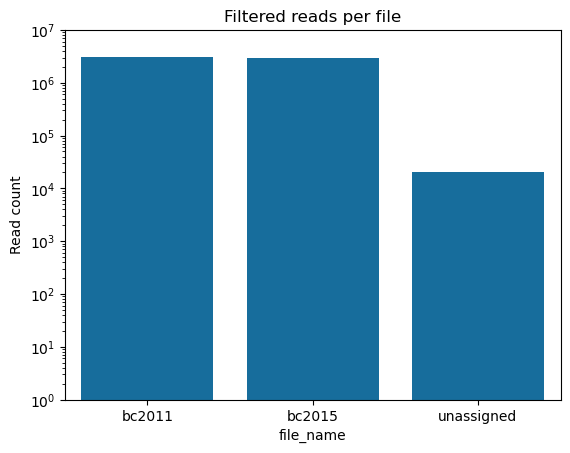

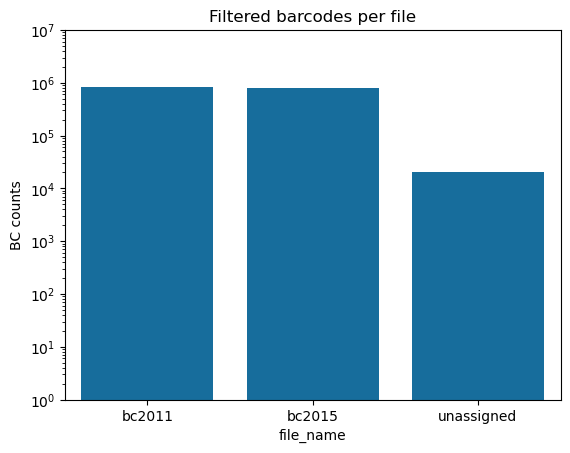

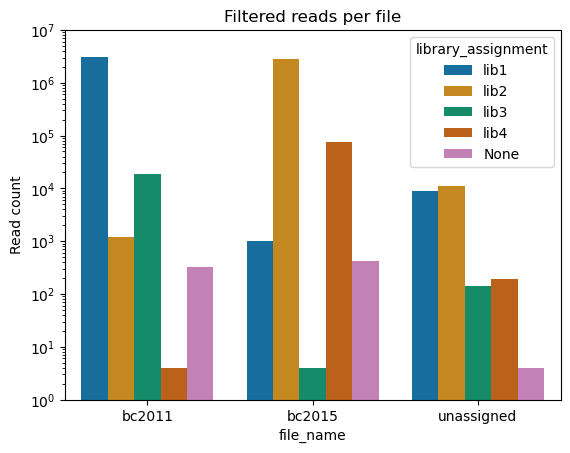

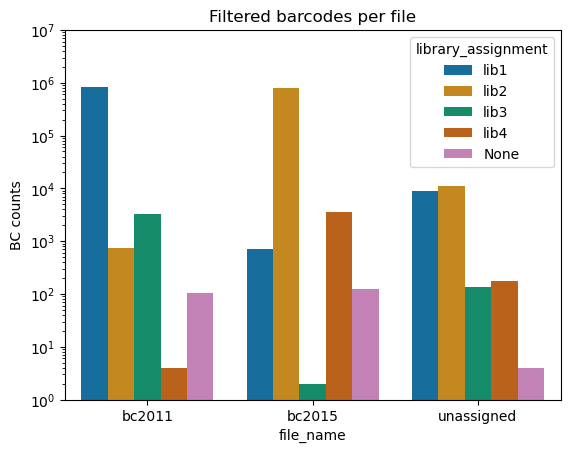

In [57]:
sns.barplot(data=good_pairs.groupby('file_name')['Read_count'].sum().rename('Read count').reset_index(), x='file_name', y='Read count', order=['bc2011', 'bc2015', 'unassigned'])
plt.yscale('log')
plt.ylim(1, 1e7)
plt.title('Filtered reads per file')
plt.show()

sns.barplot(data=(good_pairs['upstream_barcode']+good_pairs['downstream_barcode']).groupby(good_pairs['file_name']).nunique().rename('BC counts').reset_index(), x='file_name', y='BC counts', order=['bc2011', 'bc2015', 'unassigned'])
plt.yscale('log')
plt.ylim(1, 1e7)
plt.title('Filtered barcodes per file')
plt.show()

sns.barplot(data=good_pairs.groupby(['file_name','library_assignment'])['Read_count'].sum().rename('Read count').reset_index(), x='file_name', y='Read count', 
            hue='library_assignment', hue_order=['lib1', 'lib2', 'lib3', 'lib4', 'None'], order=['bc2011', 'bc2015', 'unassigned'])
plt.yscale('log')
plt.ylim(1, 1e7)
plt.title('Filtered reads per file')
plt.show()

sns.barplot(data=(good_pairs['upstream_barcode']+good_pairs['downstream_barcode']).groupby([good_pairs['file_name'], good_pairs['library_assignment']]).nunique().rename('BC counts').reset_index(), x='file_name', y='BC counts', order=['bc2011', 'bc2015', 'unassigned'],
            hue='library_assignment', hue_order=['lib1', 'lib2', 'lib3', 'lib4', 'None'])
plt.yscale('log')
plt.ylim(1, 1e7)
plt.title('Filtered barcodes per file')
plt.show()

In [24]:
def plot_count_distribution(data_df, y_col, title, group_cols=None, hue_order=None, col_order=None):
    if group_cols is None:
        group_cols = ['file_name', 'library_assignment']
    to_plot = data_df.sort_values(y_col, ascending=False)
    to_plot['Rank'] = to_plot.groupby(group_cols)[y_col].rank(method='first', ascending=False)
    g = sns.relplot(data=to_plot, col="file_name", x="Rank", y=y_col,  kind='scatter', hue='library_assignment', hue_order=hue_order, col_order=col_order,
                    edgecolor='none')
    for ax in g.axes.flat:
        ax.set_xscale('log')
        ax.set_yscale('log')
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title)
    plt.show()

    to_plot['Library_count_fraction'] = to_plot.groupby(group_cols, group_keys=False)[y_col].apply(lambda x: x/x.sum())
    g = sns.relplot(data=to_plot, col="file_name", x="Rank", y="Library_count_fraction", kind='scatter', hue='library_assignment', hue_order=hue_order, col_order=col_order,
                    edgecolor='none')
    for ax in g.axes.flat:
        ax.set_xscale('log')
        ax.set_yscale('log')
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title)
    plt.show()

    to_plot = data_df.copy().sort_values(y_col, ascending=True)
    to_plot['Cumulative_count_fraction'] = to_plot.groupby(group_cols, group_keys=False)[y_col].apply(lambda x: x.cumsum()/x.sum())
    to_plot['Cumulative_Rank_fraction'] = to_plot.groupby(group_cols)[y_col].rank(method='first', ascending=True).sort_values().groupby([to_plot[col] for col in group_cols], group_keys=False).apply(lambda x: x/(len(x)))

    g = sns.relplot(data=to_plot, col="file_name", x="Cumulative_Rank_fraction", y="Cumulative_count_fraction", kind='scatter', hue='library_assignment', hue_order=hue_order, col_order=col_order,
                    edgecolor='none')
    g.map_dataframe(lambda *args, **kwargs: plt.plot([0, 1], [0, 1], color='black', alpha=0.5))
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title)
    plt.show()
    def gini(sorted_arr):
        n = sorted_arr.size
        coef_ = 2. / n
        const_ = (n + 1.) / n
        weighted_sum = sum([(i+1)*yi for i, yi in enumerate(sorted_arr)])
        return coef_*weighted_sum/(sorted_arr.sum()) - const_

    print('gini coefficient')
    display(to_plot.groupby(group_cols)[y_col].apply(gini).rename('Gini_coefficient').reset_index())

    to_plot = data_df.copy()
    g = sns.FacetGrid(data=to_plot, col="file_name", col_wrap=3, col_order=col_order)
    g.map_dataframe(sns.histplot, x=y_col, hue='library_assignment', multiple='stack', discrete=True, hue_order=hue_order)
    plt.subplots_adjust(top=0.85)
    plt.suptitle(title)
    plt.show()

    to_plot = to_plot.groupby(group_cols)[y_col].value_counts().reset_index()
    g = sns.relplot(data=to_plot, x=y_col, y='count', col='file_name', hue='library_assignment', kind='scatter', hue_order=hue_order, col_order=col_order,
                    edgecolor='none')
    for ax in g.axes.flat:
        ax.set_yscale('log')
    plt.subplots_adjust(top=0.9)
    plt.suptitle(title)
    plt.show()

    to_plot = data_df.copy()
    print(f'{y_col} summary')
    display(to_plot.groupby(group_cols)[y_col].describe().reset_index())

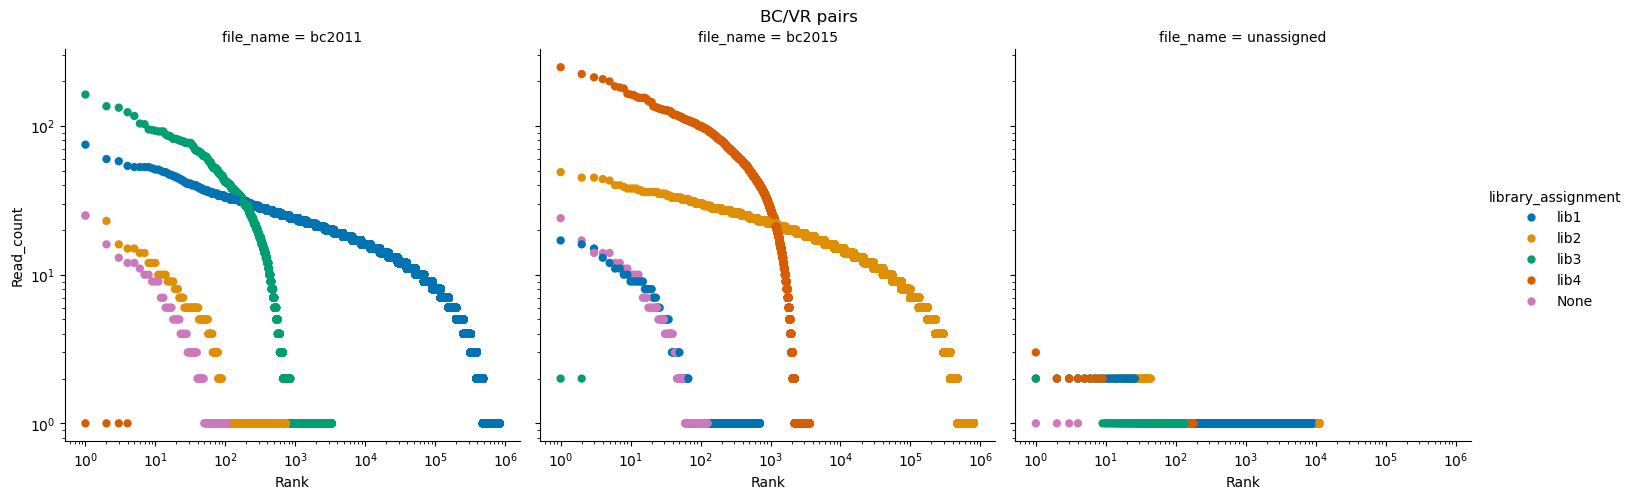

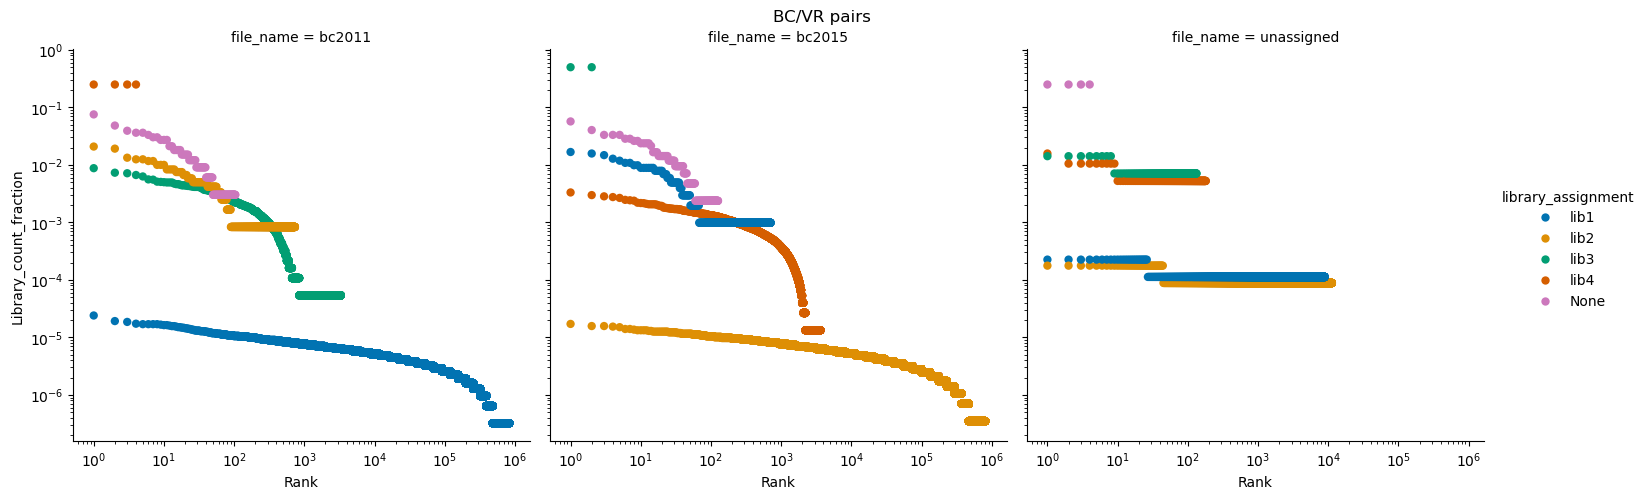

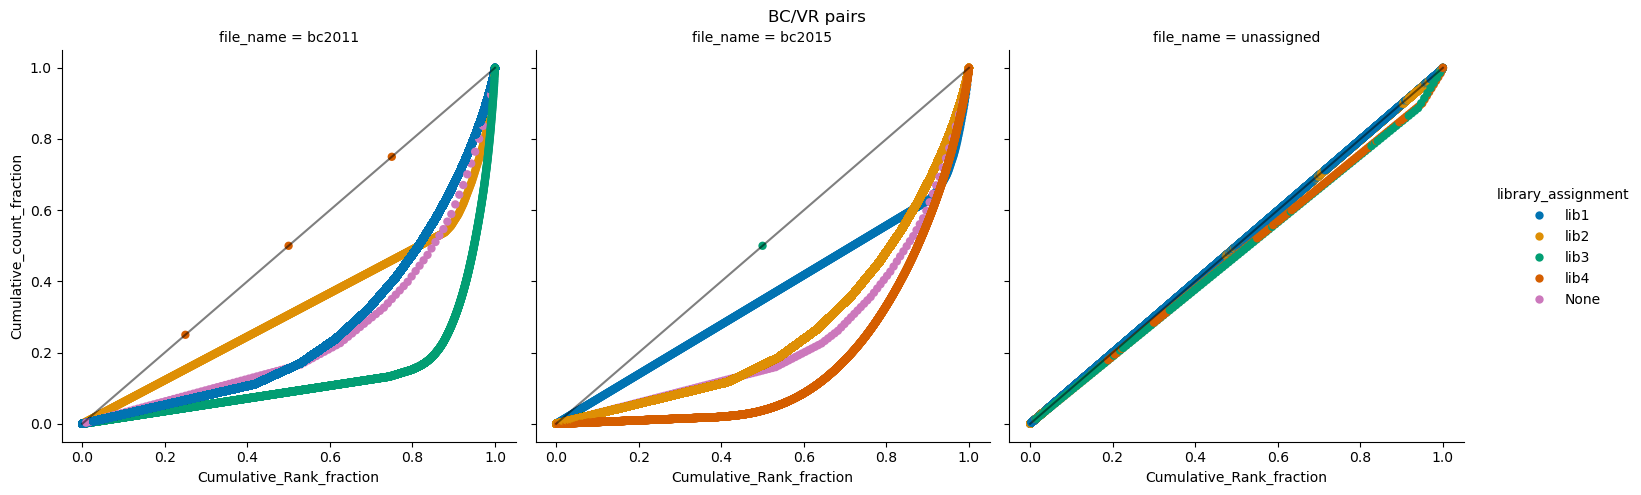

gini coefficient


,file_name,library_assignment,Gini_coefficient
0,bc2011,None,0.510196
1,bc2011,lib1,0.482349
2,bc2011,lib2,0.359422
3,bc2011,lib3,0.736633
4,bc2011,lib4,0.000000
5,bc2015,None,0.519153
6,bc2015,lib1,0.287429
7,bc2015,lib2,0.470829
8,bc2015,lib3,0.000000
9,bc2015,lib4,0.661950


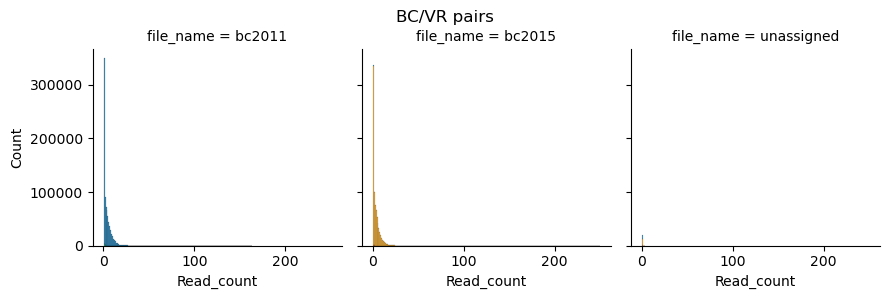

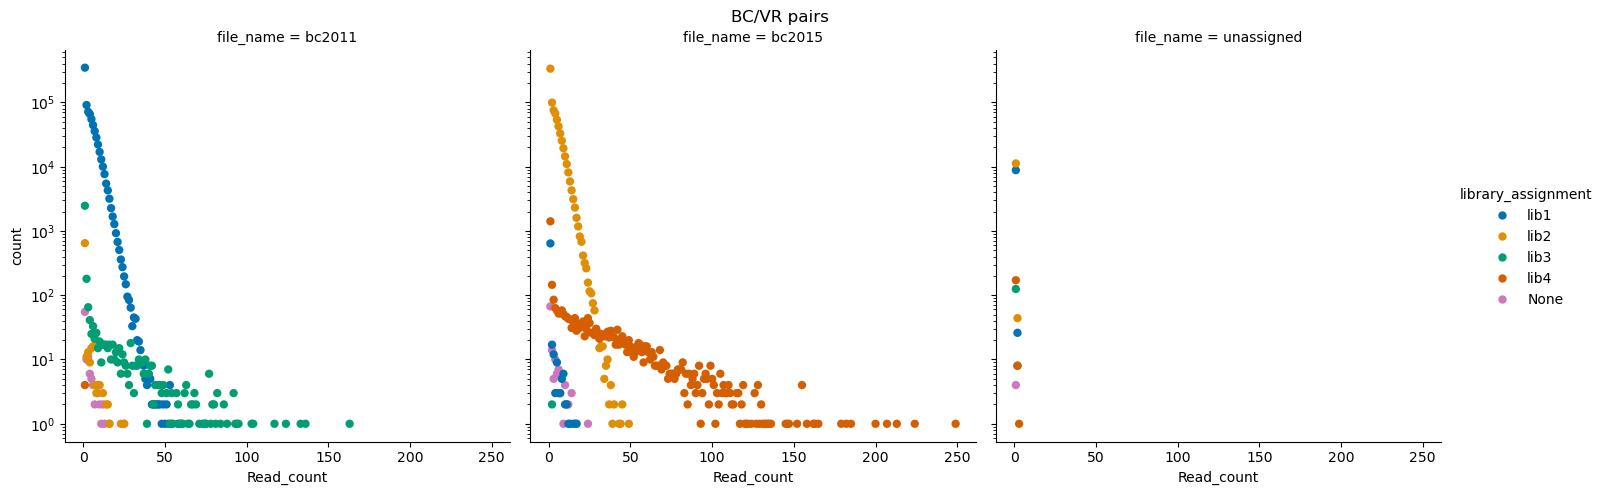

Read_count summary


,file_name,library_assignment,count,mean,std,min,25%,50%,75%,max
0,bc2011,None,104.0,3.182692,3.823190,1.0,1.0,1.0,4.0,25.0
1,bc2011,lib1,828882.0,3.762130,3.717352,1.0,1.0,2.0,5.0,75.0
2,bc2011,lib2,734.0,1.633515,2.258353,1.0,1.0,1.0,1.0,25.0
3,bc2011,lib3,3309.0,5.616198,13.695388,1.0,1.0,1.0,2.0,163.0
4,bc2011,lib4,4.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
5,bc2015,None,126.0,3.341270,3.933777,1.0,1.0,1.0,4.0,24.0
6,bc2015,lib1,706.0,1.436261,1.773577,1.0,1.0,1.0,1.0,17.0
7,bc2015,lib2,804419.0,3.548735,3.426540,1.0,1.0,2.0,5.0,49.0
8,bc2015,lib3,2.0,2.000000,0.000000,2.0,2.0,2.0,2.0,2.0
9,bc2015,lib4,3625.0,20.699034,29.195838,1.0,1.0,6.0,31.0,249.0


In [25]:
plot_count_distribution(good_pairs.copy(), 'Read_count', 'BC/VR pairs', hue_order=['lib1', 'lib2', 'lib3', 'lib4', 'None'], col_order=['bc2011', 'bc2015', 'unassigned'])

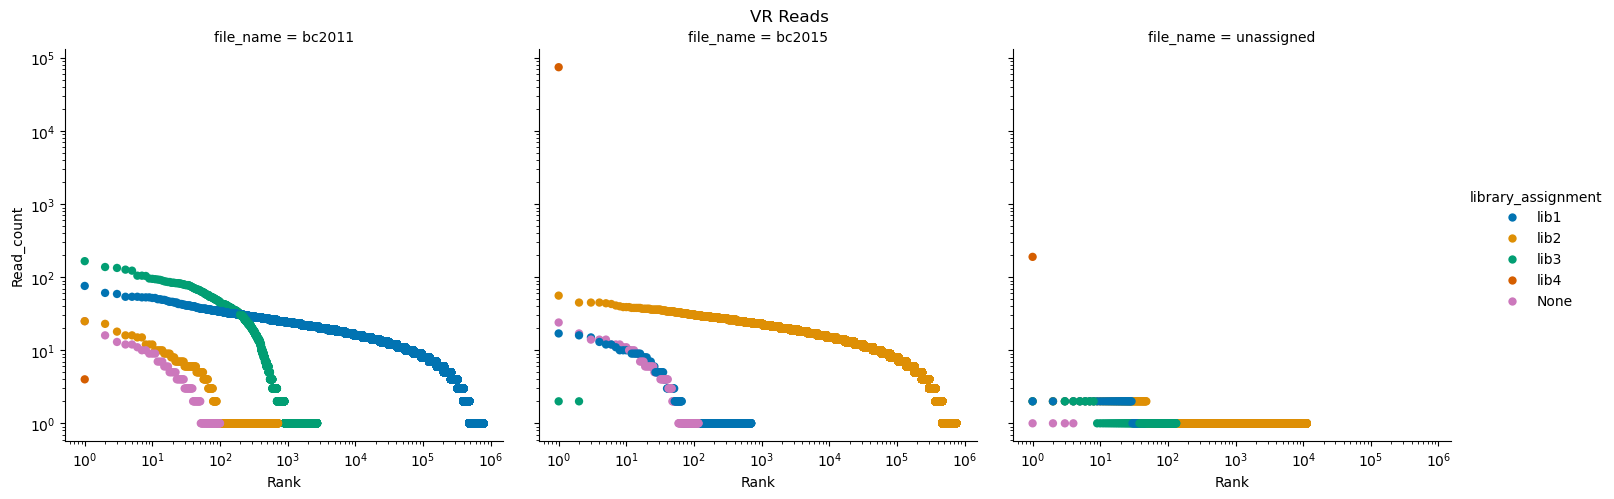

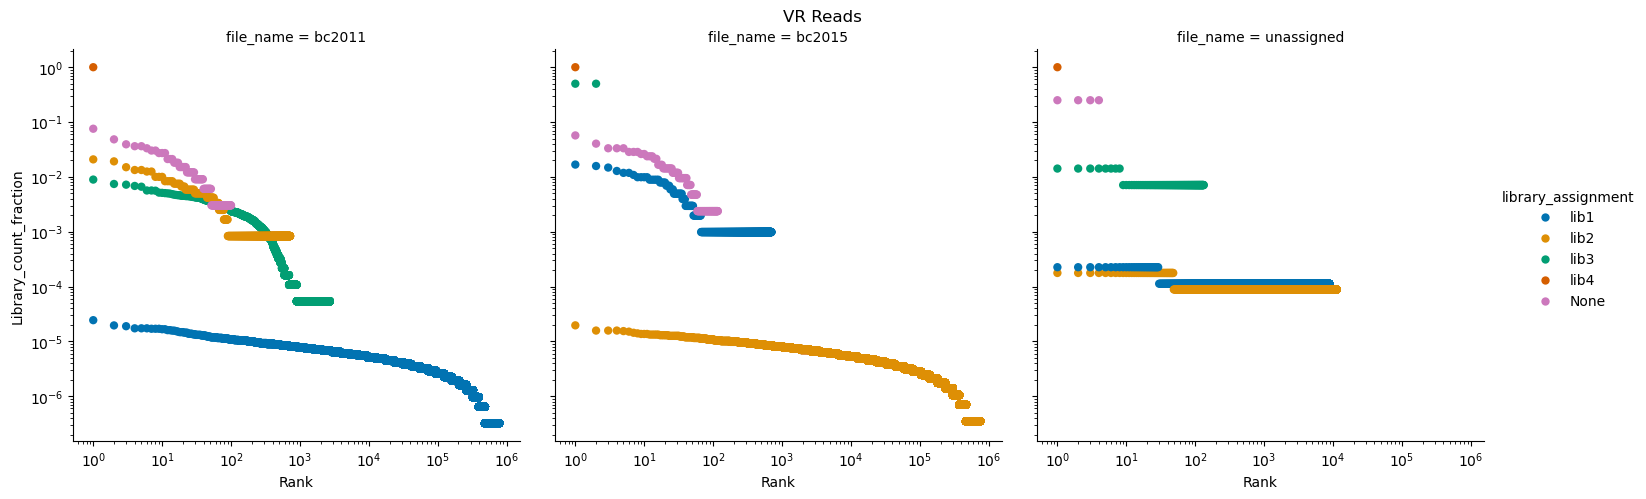

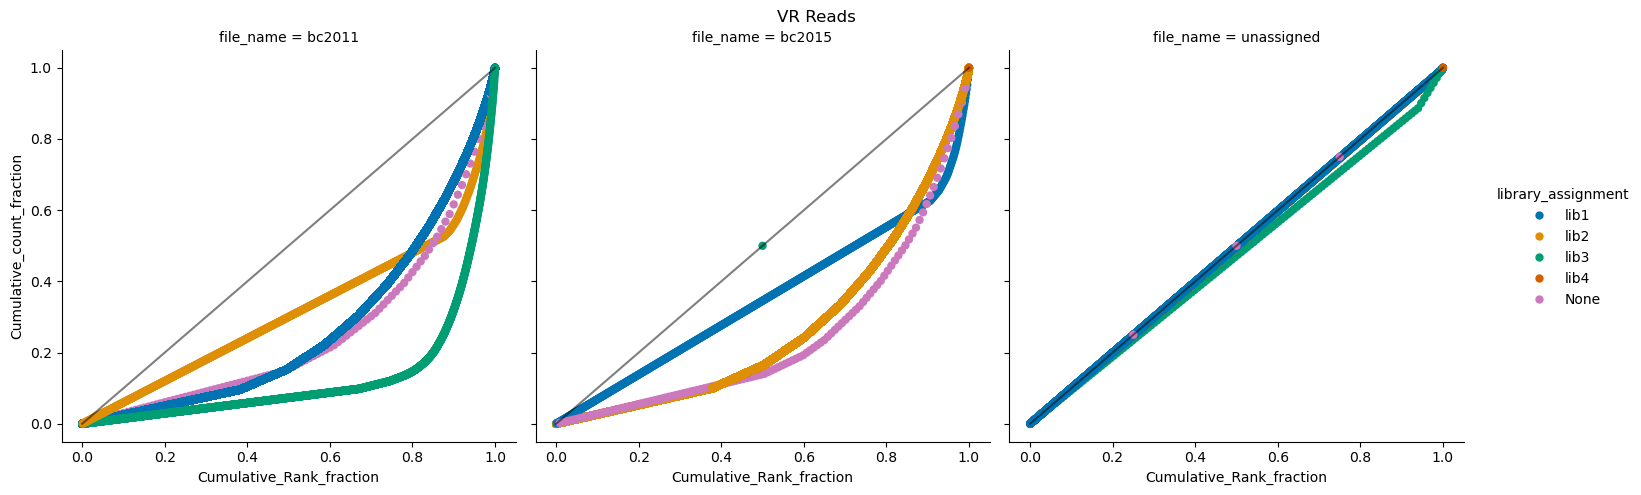

gini coefficient


,file_name,library_assignment,Gini_coefficient
0,bc2011,None,0.506677
1,bc2011,lib1,0.476408
2,bc2011,lib2,0.369791
3,bc2011,lib3,0.746437
4,bc2011,lib4,0.000000
5,bc2015,None,0.518749
6,bc2015,lib1,0.292065
7,bc2015,lib2,0.466463
8,bc2015,lib3,0.000000
9,bc2015,lib4,0.000000


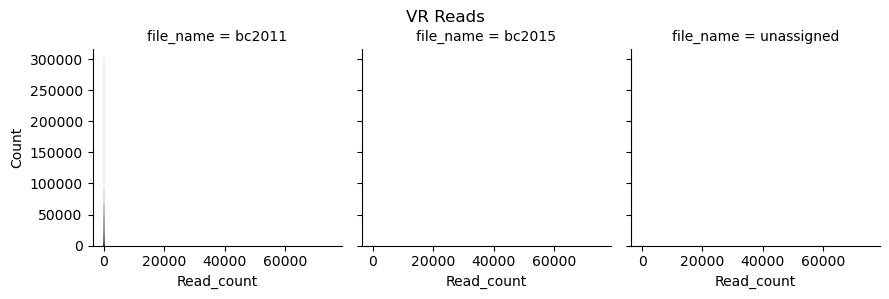

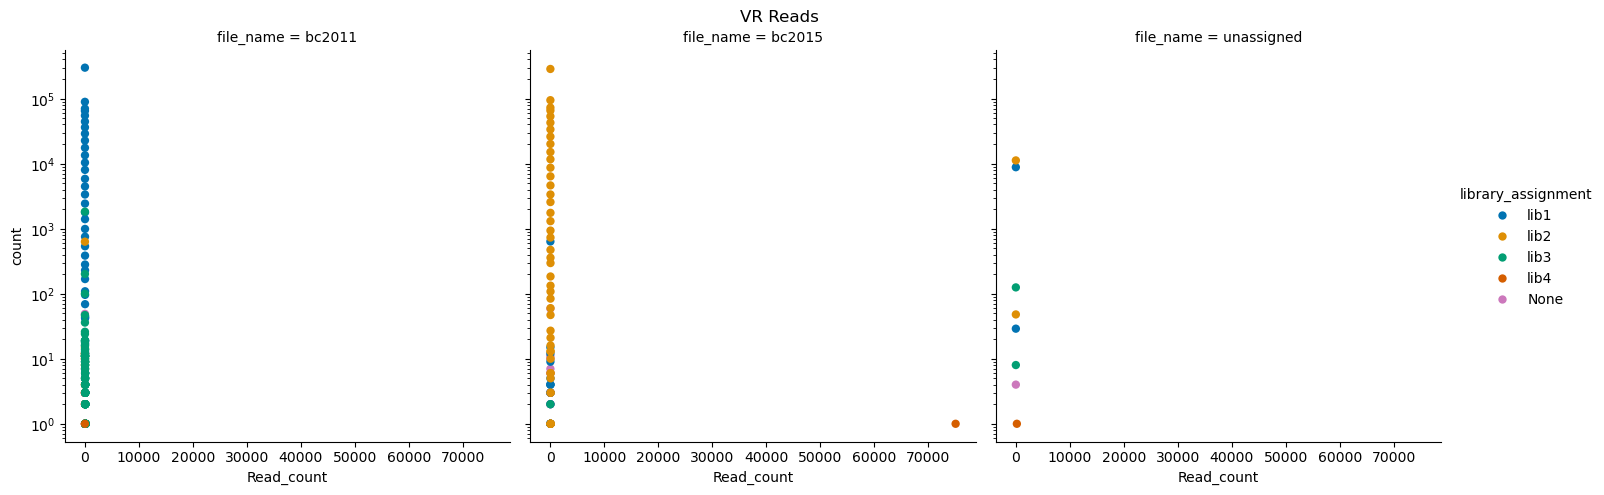

Read_count summary


,file_name,library_assignment,count,mean,std,min,25%,50%,75%,max
0,bc2011,None,100.0,3.310000,3.873492,1.0,1.0,2.0,4.0,25.0
1,bc2011,lib1,782321.0,3.986039,3.830715,1.0,1.0,3.0,6.0,76.0
2,bc2011,lib2,720.0,1.665278,2.348714,1.0,1.0,1.0,1.0,25.0
3,bc2011,lib3,2719.0,6.834866,15.537830,1.0,1.0,1.0,3.0,166.0
4,bc2011,lib4,1.0,4.000000,NaN,4.0,4.0,4.0,4.0,4.0
5,bc2015,None,117.0,3.598291,4.089642,1.0,1.0,1.0,5.0,24.0
6,bc2015,lib1,701.0,1.446505,1.808410,1.0,1.0,1.0,1.0,17.0
7,bc2015,lib2,753049.0,3.790816,3.565327,1.0,1.0,2.0,5.0,56.0
8,bc2015,lib3,2.0,2.000000,0.000000,2.0,2.0,2.0,2.0,2.0
9,bc2015,lib4,1.0,75034.000000,NaN,75034.0,75034.0,75034.0,75034.0,75034.0


In [26]:
plot_count_distribution(good_pairs.groupby(['file_name', 'library_assignment', 'lib001_variable_exon','lib001_variable_intron','lib002_variable_exon','lib002_variable_intron','lib003_variable_exon','lib004_junction'], dropna=False)['Read_count'].sum().reset_index(), 'Read_count', 'VR Reads', hue_order=['lib1', 'lib2', 'lib3', 'lib4', 'None'], col_order=['bc2011', 'bc2015', 'unassigned'])

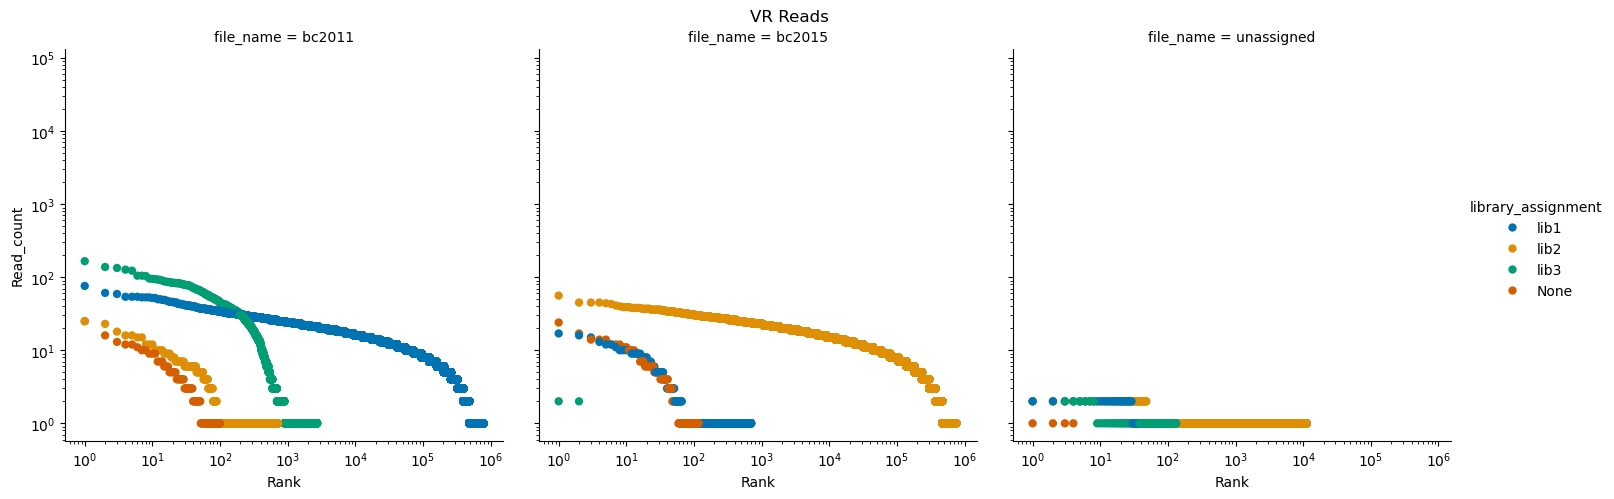

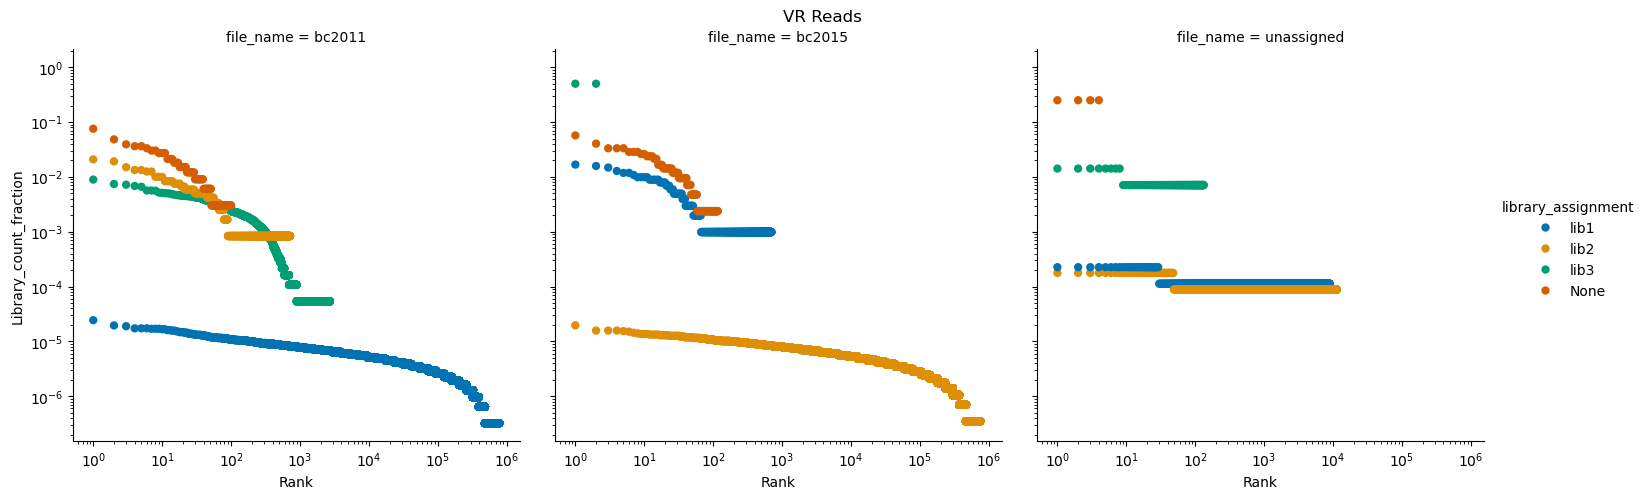

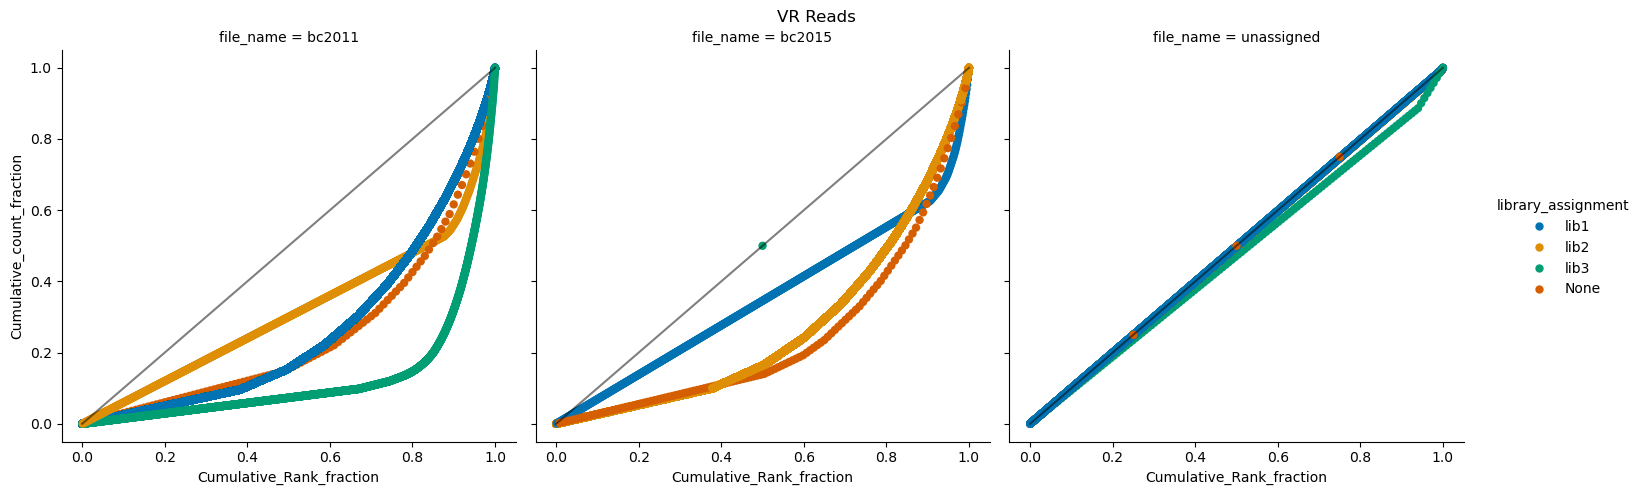

gini coefficient


,file_name,library_assignment,Gini_coefficient
0,bc2011,None,0.506677
1,bc2011,lib1,0.476408
2,bc2011,lib2,0.369791
3,bc2011,lib3,0.746437
4,bc2011,lib4,0.000000
5,bc2015,None,0.518749
6,bc2015,lib1,0.292065
7,bc2015,lib2,0.466463
8,bc2015,lib3,0.000000
9,bc2015,lib4,0.000000


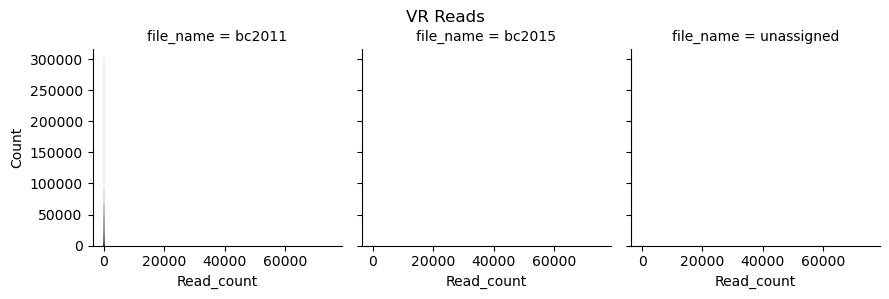

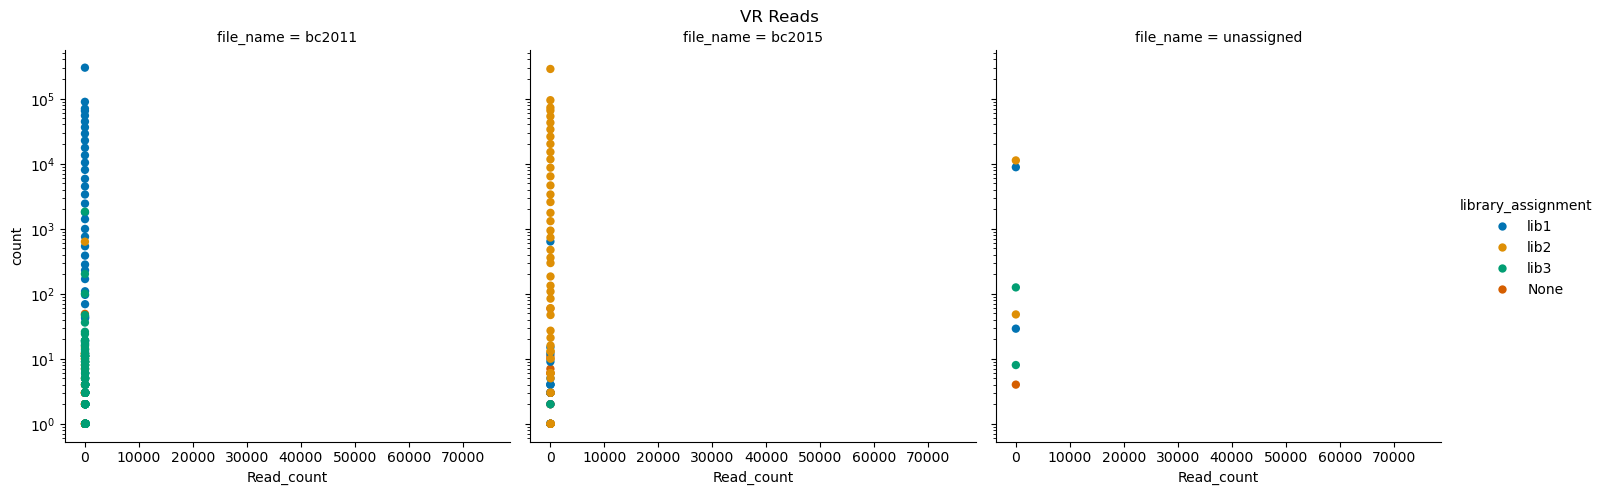

Read_count summary


,file_name,library_assignment,count,mean,std,min,25%,50%,75%,max
0,bc2011,None,100.0,3.310000,3.873492,1.0,1.0,2.0,4.0,25.0
1,bc2011,lib1,782321.0,3.986039,3.830715,1.0,1.0,3.0,6.0,76.0
2,bc2011,lib2,720.0,1.665278,2.348714,1.0,1.0,1.0,1.0,25.0
3,bc2011,lib3,2719.0,6.834866,15.537830,1.0,1.0,1.0,3.0,166.0
4,bc2011,lib4,1.0,4.000000,NaN,4.0,4.0,4.0,4.0,4.0
5,bc2015,None,117.0,3.598291,4.089642,1.0,1.0,1.0,5.0,24.0
6,bc2015,lib1,701.0,1.446505,1.808410,1.0,1.0,1.0,1.0,17.0
7,bc2015,lib2,753049.0,3.790816,3.565327,1.0,1.0,2.0,5.0,56.0
8,bc2015,lib3,2.0,2.000000,0.000000,2.0,2.0,2.0,2.0,2.0
9,bc2015,lib4,1.0,75034.000000,NaN,75034.0,75034.0,75034.0,75034.0,75034.0


In [27]:
plot_count_distribution(good_pairs.groupby(['file_name', 'library_assignment', 'lib001_variable_exon','lib001_variable_intron','lib002_variable_exon','lib002_variable_intron','lib003_variable_exon','lib004_junction'], dropna=False)['Read_count'].sum().reset_index(), 'Read_count', 'VR Reads', hue_order=['lib1', 'lib2', 'lib3', 'None'], col_order=['bc2011', 'bc2015', 'unassigned'])

In [28]:
to_plot = good_pairs.copy()
to_plot['BC'] = to_plot['upstream_barcode']+to_plot['downstream_barcode']
to_plot

,index,file_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction,library_assignment,Read_count,keep_mask,BC
0,0,bc2011,A,CTCACATACAATAGTTAAGC,TCAGTCCTAACTTAATTTCCATATCTACTGGTTATGGTTTATTCAC...,AGAGCCGAATTGCAGTTGATTAGAAGTAATAGTACACTAT,NaN,NaN,NaN,NaN,lib1,1,True,ACTCACATACAATAGTTAAGC
1,1,bc2011,A,CTTACACTCGTAAAAACGAG,CGTTTAGGGAGAAAGTGGACGTTGTACATATCTCACGTGCAGCATC...,TGGCCTTTGGTTTTGCTTTTTTATTACTATCCTACTAAAG,NaN,NaN,NaN,NaN,lib1,1,True,ACTTACACTCGTAAAAACGAG
2,2,bc2011,A,TAGAAGTGTACGGTTCTGGA,CTGACCTCCTTAAAAAAAATTGCACTGTCTTTTTGAACAGTATCCC...,ATGTATGGGCTAGCCTTTATCCCCAGTACAGTTTCGGTCT,NaN,NaN,NaN,NaN,lib1,3,True,ATAGAAGTGTACGGTTCTGGA
3,3,bc2011,A,TGCCAAAAAACGCGCTCTCA,AGAAGATCGGTTTATAAATTTATAATTCTTATGGCTTATTCCTTAT...,CGTGTGTTAGGTGGGAATATGTAAACATTCCGAGACCGAC,NaN,NaN,NaN,NaN,lib1,7,True,ATGCCAAAAAACGCGCTCTCA
4,4,bc2011,A,TGCCAAAAACGCGCTCTCA,AGAAGATCGGTTTATAAATTTATAATTCTTATGGCTTATTCCTTAT...,CGTGTGTTAGGTGGGAATATGTAAACATTCCGAGACCGAC,NaN,NaN,NaN,NaN,lib1,2,True,ATGCCAAAAACGCGCTCTCA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2453049,2453049,unassigned,TTTTTT,GAGATTCCCAAGCATGACCA,TGGCTACATCTTTTTTGATTTTCGATAGGGTTGATCTTCTAAGTTC...,GTTTGGAGTTCTACTCACAAGGGTTGGATATCGACTCTGC,NaN,NaN,NaN,NaN,lib1,1,True,TTTTTTGAGATTCCCAAGCATGACCA
2453050,2453050,unassigned,TTTTTT,GTACTGTCTCCCTTGTGGGC,NaN,NaN,TAGGTGTTTCGGGAACTATAATATGGGTTCGGCCTTTCTGCAATTG...,TGGACGTTTAGACTGCGGTGGAGTCTATTCTTAGGCATT,NaN,NaN,lib2,1,True,TTTTTTGTACTGTCTCCCTTGTGGGC
2453051,2453051,unassigned,TTTTTT,TGCAATCGTCTCAACAGCGC,GAGTGTTATGTTGTTTAATGTCACTGGAATTATTTCTAATATTCTA...,ATGTCTGGGCTTCATCTGCTCGTTCCGTTTGGAGACACCT,NaN,NaN,NaN,NaN,lib1,1,True,TTTTTTTGCAATCGTCTCAACAGCGC
2453052,2453052,unassigned,TTTTTT,TTTAAACCGTTTTTTACCGAT,NaN,NaN,GGAATATATTTTTTGACGCTCACCGGCAAGTGATTACTCGTAGCTA...,TTTATTCTCTTACTTTAAACAGAATGGAGCCTTATGTTTC,NaN,NaN,lib2,1,True,TTTTTTTTTAAACCGTTTTTTACCGAT


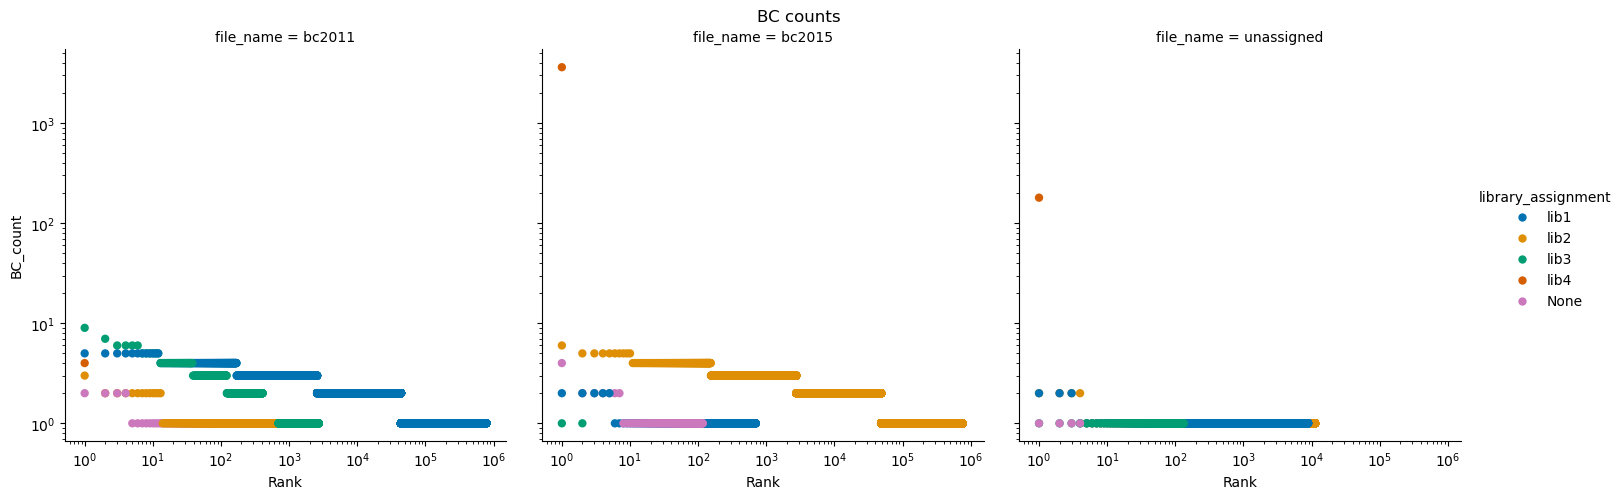

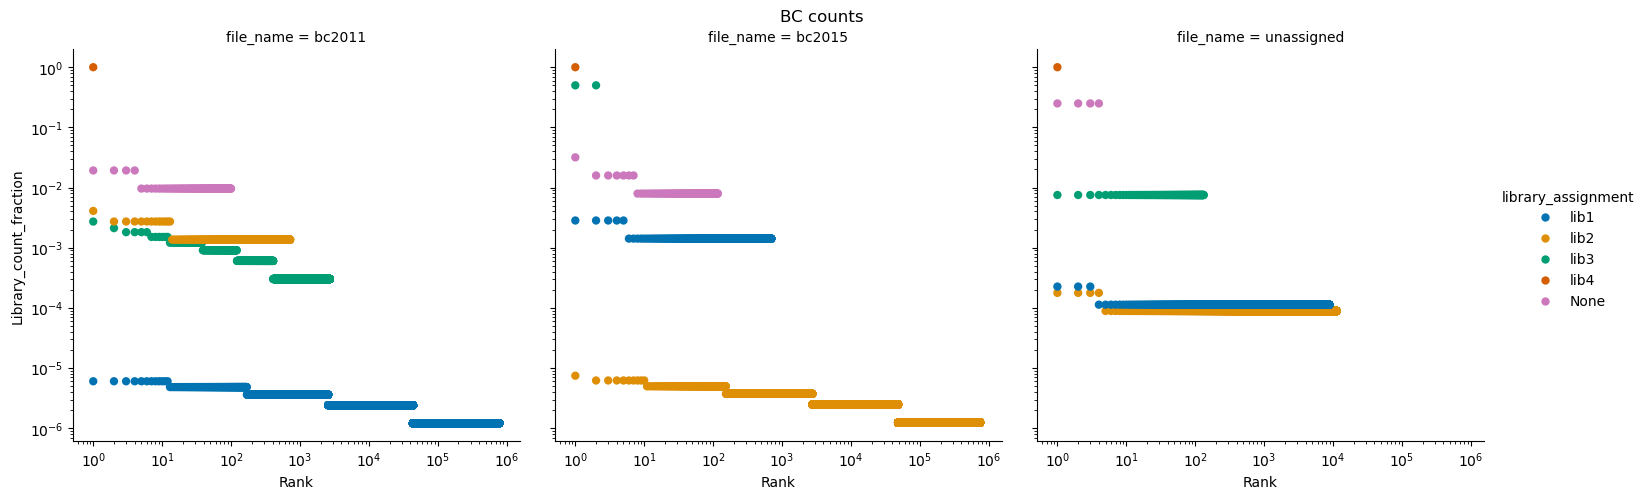

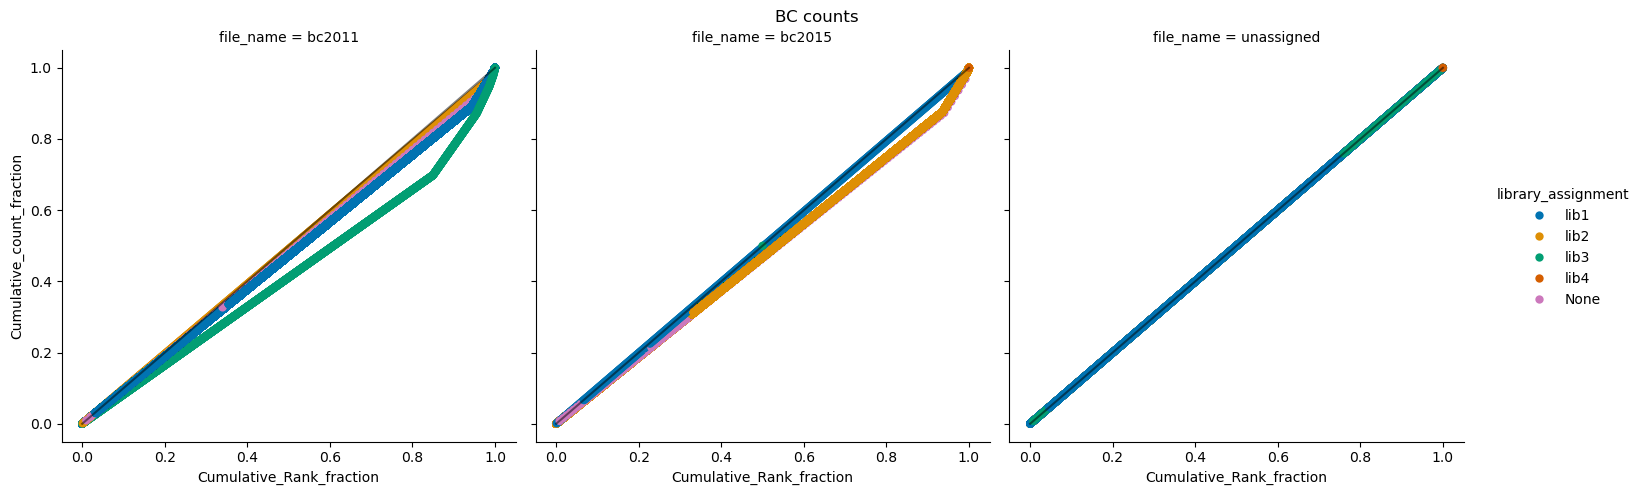

gini coefficient


,file_name,library_assignment,Gini_coefficient
0,bc2011,None,0.036923
1,bc2011,lib1,0.053200
2,bc2011,lib2,0.018752
3,bc2011,lib3,0.157901
4,bc2011,lib4,0.000000
5,bc2015,None,0.067969
6,bc2015,lib1,0.007032
7,bc2015,lib2,0.059966
8,bc2015,lib3,0.000000
9,bc2015,lib4,0.000000


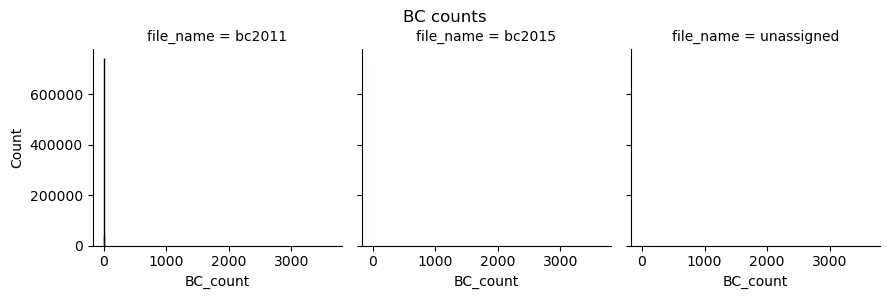

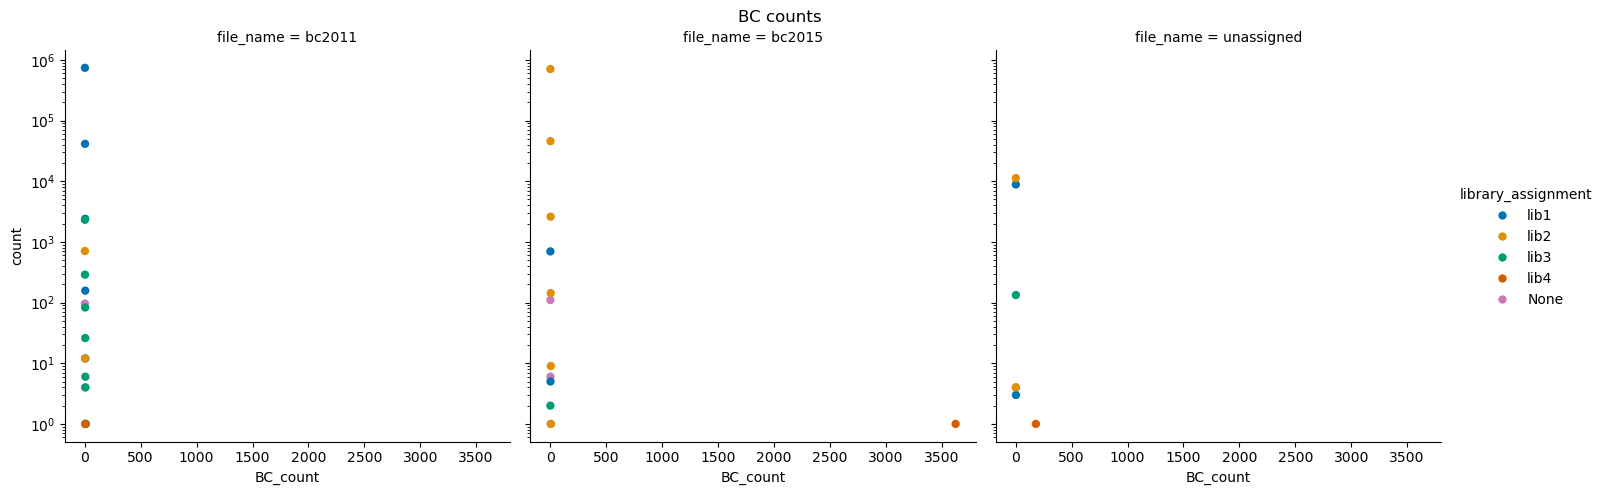

BC_count summary


,file_name,library_assignment,count,mean,std,min,25%,50%,75%,max
0,bc2011,None,100.0,1.040000,0.196946,1.0,1.0,1.0,1.0,2.0
1,bc2011,lib1,782321.0,1.059511,0.252000,1.0,1.0,1.0,1.0,5.0
2,bc2011,lib2,720.0,1.019444,0.147900,1.0,1.0,1.0,1.0,3.0
3,bc2011,lib3,2719.0,1.216992,0.613190,1.0,1.0,1.0,1.0,9.0
4,bc2011,lib4,1.0,4.000000,NaN,4.0,4.0,4.0,4.0,4.0
5,bc2015,None,117.0,1.076923,0.351201,1.0,1.0,1.0,1.0,4.0
6,bc2015,lib1,701.0,1.007133,0.084213,1.0,1.0,1.0,1.0,2.0
7,bc2015,lib2,753049.0,1.068208,0.267910,1.0,1.0,1.0,1.0,6.0
8,bc2015,lib3,2.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
9,bc2015,lib4,1.0,3625.000000,NaN,3625.0,3625.0,3625.0,3625.0,3625.0


In [29]:
plot_count_distribution(to_plot.groupby(['file_name', 'library_assignment', 'lib001_variable_exon','lib001_variable_intron','lib002_variable_exon','lib002_variable_intron','lib003_variable_exon','lib004_junction'], dropna=False)['BC'].nunique().rename('BC_count').reset_index(), 'BC_count', 'BC counts', hue_order=['lib1', 'lib2', 'lib3', 'lib4', 'None'], col_order=['bc2011', 'bc2015', 'unassigned'])

In [30]:
multi_bcs = (
    to_plot[
        (to_plot['library_assignment'] != 'Lib004') & (to_plot['library_assignment'] != 'None')
    ]
    .groupby([
        'file_name',
        'library_assignment',
        'lib001_variable_exon',
        'lib001_variable_intron',
        'lib002_variable_exon',
        'lib002_variable_intron',
        'lib003_variable_exon',
        'lib004_junction'
    ], dropna=False)
    .filter(lambda x: x['BC'].nunique() > 1)
)
multi_bcs


,index,file_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction,library_assignment,Read_count,keep_mask,BC
3,3,bc2011,A,TGCCAAAAAACGCGCTCTCA,AGAAGATCGGTTTATAAATTTATAATTCTTATGGCTTATTCCTTAT...,CGTGTGTTAGGTGGGAATATGTAAACATTCCGAGACCGAC,NaN,NaN,NaN,NaN,lib1,7,True,ATGCCAAAAAACGCGCTCTCA
4,4,bc2011,A,TGCCAAAAACGCGCTCTCA,AGAAGATCGGTTTATAAATTTATAATTCTTATGGCTTATTCCTTAT...,CGTGTGTTAGGTGGGAATATGTAAACATTCCGAGACCGAC,NaN,NaN,NaN,NaN,lib1,2,True,ATGCCAAAAACGCGCTCTCA
12,12,bc2011,AAAA,GTCCTGAAGCAACAAGTTAT,AAACTTCGTTCATCCAGTGATTCCGATTTTAGATATTGTGTTCCTG...,GGCTCGGATTAGCATGTTTCATTGGGTACAAGGTTGCTAG,NaN,NaN,NaN,NaN,lib1,1,True,AAAAGTCCTGAAGCAACAAGTTAT
14,14,bc2011,AAAAA,AAAACCGTTGTGTTTGGACT,CCAGGTTGATAACGTCGAGCTGTGAGAATGTGGTCCTCTATAGCTT...,CAGATTATTCGTGCTCACGTTCAGTTTAAGCTCTTCATTA,NaN,NaN,NaN,NaN,lib1,1,True,AAAAAAAAACCGTTGTGTTTGGACT
15,15,bc2011,AAAAA,AAAGACGCGACGACAGCTAA,GTGGTTATTGTTATGATAATTACTTATTCTTTCCGCGTTTAGTATA...,ATGGGTTGAACTTTGATCTGAAATTGGTAGACAGCATACG,NaN,NaN,NaN,NaN,lib1,2,True,AAAAAAAAGACGCGACGACAGCTAA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2452770,2452770,unassigned,TTTGAC,ATTCGCGTCCAACCCCTTCT,NaN,NaN,NaN,NaN,NaN,CCCTGGGCAGCTCCTGGGCA,lib4,1,True,TTTGACATTCGCGTCCAACCCCTTCT
2452835,2452835,unassigned,TTTGGC,ATTAACTACGTCCACACGCG,NaN,NaN,NaN,NaN,NaN,CCCTGGGCAGCTCCTGGGCA,lib4,1,True,TTTGGCATTAACTACGTCCACACGCG
2452967,2452967,unassigned,TTTTCT,GAGCCGTAAAATAGAAAAGA,NaN,NaN,NaN,NaN,NaN,CCCTGGGCAGCTCCTGGGCA,lib4,1,True,TTTTCTGAGCCGTAAAATAGAAAAGA
2452969,2452969,unassigned,TTTTCT,GGCGCAGTTAATAAATGAAA,NaN,NaN,NaN,NaN,NaN,CCCTGGGCAGCTCCTGGGCA,lib4,1,True,TTTTCTGGCGCAGTTAATAAATGAAA


In [31]:
multi_bcs.sort_values(['file_name','BC'], ascending=False)

,index,file_name,upstream_barcode,downstream_barcode,lib001_variable_exon,lib001_variable_intron,lib002_variable_exon,lib002_variable_intron,lib003_variable_exon,lib004_junction,library_assignment,Read_count,keep_mask,BC
2452980,2452980,unassigned,TTTTGA,GAAAGAATTTAGGACCATCC,NaN,NaN,NaN,NaN,NaN,CCCTGGGCAGCTCCTGGGCA,lib4,2,True,TTTTGAGAAAGAATTTAGGACCATCC
2452969,2452969,unassigned,TTTTCT,GGCGCAGTTAATAAATGAAA,NaN,NaN,NaN,NaN,NaN,CCCTGGGCAGCTCCTGGGCA,lib4,1,True,TTTTCTGGCGCAGTTAATAAATGAAA
2452967,2452967,unassigned,TTTTCT,GAGCCGTAAAATAGAAAAGA,NaN,NaN,NaN,NaN,NaN,CCCTGGGCAGCTCCTGGGCA,lib4,1,True,TTTTCTGAGCCGTAAAATAGAAAAGA
2452835,2452835,unassigned,TTTGGC,ATTAACTACGTCCACACGCG,NaN,NaN,NaN,NaN,NaN,CCCTGGGCAGCTCCTGGGCA,lib4,1,True,TTTGGCATTAACTACGTCCACACGCG
2452770,2452770,unassigned,TTTGAC,ATTCGCGTCCAACCCCTTCT,NaN,NaN,NaN,NaN,NaN,CCCTGGGCAGCTCCTGGGCA,lib4,1,True,TTTGACATTCGCGTCCAACCCCTTCT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,99,bc2011,AAAAAA,AAAGACGCGACGACAGCTAA,GTGGTTATTGTTATGATAATTACTTATTCTTTCCGCGTTTAGTATA...,ATGGGTTGAACTTTGATCTGAAATTGGTAGACAGCATACG,NaN,NaN,NaN,NaN,lib1,2,True,AAAAAAAAAGACGCGACGACAGCTAA
14,14,bc2011,AAAAA,AAAACCGTTGTGTTTGGACT,CCAGGTTGATAACGTCGAGCTGTGAGAATGTGGTCCTCTATAGCTT...,CAGATTATTCGTGCTCACGTTCAGTTTAAGCTCTTCATTA,NaN,NaN,NaN,NaN,lib1,1,True,AAAAAAAAACCGTTGTGTTTGGACT
98,98,bc2011,AAAAAA,AAACATCCGTAAAGGGGAA,TGCTTTATTTTTTACACTCTTTCCGTCAAAGGATAAGAAATCTTTT...,AGGGTATTGACTTGGCATACGCACAACTCTAACCGGCGGG,NaN,NaN,NaN,NaN,lib1,1,True,AAAAAAAAACATCCGTAAAGGGGAA
97,97,bc2011,AAAAAA,AAACATCCCGTAAAGGGGAA,TGCTTTATTTTTTACACTCTTTCCGTCAAAGGATAAGAAATCTTTT...,AGGGTATTGACTTGGCATACGCACAACTCTAACCGGCGGG,NaN,NaN,NaN,NaN,lib1,3,True,AAAAAAAAACATCCCGTAAAGGGGAA
